<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
    Credit Card Fraud Detection


     
</center></p></h1>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;"> Step 1 | Objective </font><br>
 <br>   
<br>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 8px;
            background:#F2FFFF">

 <p style="text-align: justify;
              font-family: cursive;
              font-size: 15px;
              color: green;
              font-weight: bold;">
        🔹 Handling Imbalanced Data with Python
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px;">
        <b>Credit Card Fraud Detection</b> using 
        <span style="color: green; font-weight: bold;">
            SMOTE, Tomek Links, ADASYN, and Random Oversampling
        </span>
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px;">
        <b>Dataset:</b> Credit Card Transactions
    </p>

  <ul style="font-family: cursive; font-size: 14px;">
        <li><b>Total samples:</b> 284,807</li>
        <li><b>Fraud cases:</b> 492</li>
        <li>
            <b>Fraud ratio:</b> 
            <span style="color: red; font-weight: bold;">0.172%</span> 
            (extremely imbalanced)
        </li>
    </ul>

  <p style="text-align: justify; font-family: cursive; font-size: 14px;">
        Due to the extreme class imbalance, traditional evaluation metrics such as
        <b>accuracy</b> become misleading and unreliable.
    </p>

  <p style="text-align: justify;
              font-family: cursive;
              font-size: 14px;
              color: green;
              font-weight: bold;">
         Accuracy is meaningless in this context<br>
         Focus on Recall, Precision, F1-score, and PR-AUC
    </p>

</div>


https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download&select=creditcard.csv

<a class="anchor" id="data"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;"> Step 2 | Libraries
 </font><br>
 <br>   
<br>

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score,auc
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek


import warnings 
warnings.filterwarnings('ignore')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [ ]:
data=pd.read_csv('creditcard.csv')
df=data.copy()

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.tail(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

###  Checking Dimensions of the Data.

In [7]:
df.shape

(284807, 31)

In [8]:
# the number of rows and columns in train dataset 
rows , columns = df.shape 
print ("The number of rows in train dataset : " , rows)
print ("The number of columns in train dataset : " , columns)

The number of rows in train dataset :  284807
The number of columns in train dataset :  31


In [9]:
len(df.columns)

31

<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">
<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solidrgb(0, 90, 128);
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF"><span>Obervation :</span><br>
    <ul>
        <li>This dataset includes the details of <b>284807</b> samples</li>
        <li>The number of features for the dataframe is equal to <b>31</b></li>
    </ul></div>

### 2. Checking the basic information of dataset.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

###  Checking NaN values in our Dataset.

In [11]:
df.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values"})

,Total No. of Missing Values
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [12]:
df.isna().sum().sort_values(ascending=False)

Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
V21       0
V20       0
V19       0
V18       0
V17       0
V15       0
V1        0
V14       0
V13       0
V12       0
V11       0
V10       0
V9        0
V8        0
V7        0
V6        0
V5        0
V4        0
V3        0
V2        0
Class     0
dtype: int64

<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">
<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solidrgb(0, 90, 128);
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF"><span>Obervation :</span><br>
    <ul>
        <li>We can observe that **none of the features is having Missing values <b>0</b> </li>
    </ul></div>

###  Checking Duplicate Values.

In [13]:
print("Duplicate Values =",df.duplicated().sum())

Duplicate Values = 1081


<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">
<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solidrgb(0, 90, 128);
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF"><span>Obervation :</span><br>
    <ul>
        <li>From the above output we can say that there is <b>0</b> </li>
    </ul></div>

In [16]:
df = df.drop_duplicates()

In [17]:
print("Duplicate rows removed:", df.duplicated().sum())


Duplicate rows removed: 0


###  Showing Only Categorical & Numerical Features.

In [18]:
df.dtypes 

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [16]:
df.select_dtypes(exclude="object").head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,23,49.85,1146.55
1,0,43,100.70,4330.10
2,1,51,97.33,4963.83
3,1,72,101.38,7299.36
4,1,25,52.22,1305.50


In [17]:
df.dtypes[df.dtypes == 'object']

customerID          object
gender              object
Partner             object
Dependents          object
PhoneService        object
MultipleLines       object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
Contract            object
PaperlessBilling    object
PaymentMethod       object
Churn               object
dtype: object

<a class="anchor" id="EDA"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;"> Step 3 | Imbalance modelsing </font><br>
 <br>   
<br>

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">Create a model</p>
</div>

##  Data Preparation

In [20]:
X = df.drop('Class', axis=1)
y = df['Class']

## Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
print(f"shape of x train: {X_train_scaled.shape}")
print(f"shape of y train: {y_train.shape}")
print(f"shape of x test: {X_test_scaled.shape}")
print(f"shape of y train: {y_test.shape}")

shape of x train: (226980, 30)
shape of y train: (226980,)
shape of x test: (56746, 30)
shape of y train: (56746,)


# Functions for Evaluation

In [ ]:
# ---------------------------
# Evaluation Function (ONLY scaled data)
# ---------------------------
def evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    conf_matrix = confusion_matrix(y_test, y_pred)

    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_curve, precision_curve)

    # ✅ Cross-Validation ONLY on scaled training data
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_mean = np.mean(cv_scores)

    print("Threshold:", threshold)
    print("\nLogistic Regression Classification Results:")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", conf_matrix)
    print("Cross-Validation Accuracy Mean:", cv_mean)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("PR-AUC:", pr_auc)
    print("-" * 50)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "conf_matrix": conf_matrix,
        "cv_accuracy": cv_mean,
        "pr_auc": pr_auc
    }



# --------------------------- Baseline ---------------------------

Threshold: 0.5

Logistic Regression Classification Results:
Accuracy: 0.9991893701758714
Precision: 0.8928571428571429
Recall: 0.5555555555555556
F1 Score: 0.684931506849315
Confusion Matrix:
 [[56650     6]
 [   40    50]]
Cross-Validation Accuracy Mean: 0.9991585161688255

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.89      0.56      0.68        90

    accuracy                           1.00     56746
   macro avg       0.95      0.78      0.84     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.7010011115062862
--------------------------------------------------


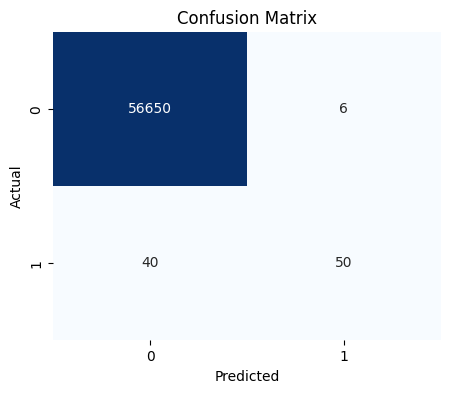

In [42]:


model = LogisticRegression(max_iter=1000, n_jobs=1)
model.fit(X_train_scaled, y_train)

results["Logistic"] = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test)

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 8px;
            background:#F2FFFF">

 <p style="text-align: justify;
              font-family: cursive;
              font-size: 15px;
              color: green;
              font-weight: bold;">
 The accuracy comes out to be 100% but did you notice something strange?

 The recall of the minority class is very low. It proves that the model is more biased towards the majority class. So, it proves that this is not the best model.

 Now, we will apply different imbalanced data handling techniques and see their accuracy and recall results.
 </p>
</div>


# --------------------------- SMOTE ---------------------------


Threshold: 0.5

Logistic Regression Classification Results:
Accuracy: 0.9750643217143059
Precision: 0.05387205387205387
Recall: 0.8888888888888888
F1 Score: 0.10158730158730159
Confusion Matrix:
 [[55251  1405]
 [   10    80]]
Cross-Validation Accuracy Mean: 0.947962682369506

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.05      0.89      0.10        90

    accuracy                           0.98     56746
   macro avg       0.53      0.93      0.54     56746
weighted avg       1.00      0.98      0.99     56746

PR-AUC: 0.7339832064755905
--------------------------------------------------


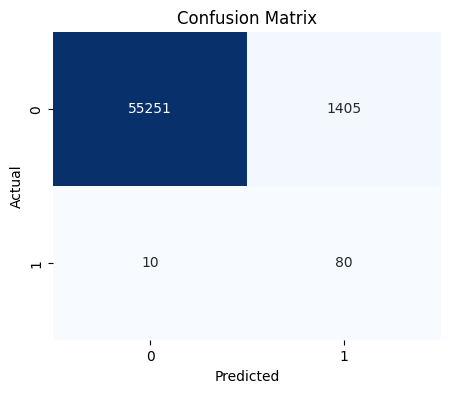

In [33]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)

model_smote = LogisticRegression(max_iter=1000, n_jobs=1)
model_smote.fit(X_smote, y_smote)

results["SMOTE"] = evaluate_model(model_smote, X_smote, y_smote, X_test_scaled, y_test)

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 8px;
            background:#F2FFFF">

  <p style="text-align: justify;
            font-family: cursive;
            font-size: 15px;
            color: green;
            font-weight: bold;">

  🔹 <strong>Model Performance Insight (Threshold = 0.5)</strong><br><br>

 The Logistic Regression model achieved a high overall accuracy of <strong>97.51%</strong>.  
    However, this is misleading because the dataset is highly imbalanced (fraud cases are very few).  
  The model detects most fraud cases correctly with a <strong>Recall of 88.89%</strong>.  
    But the <strong>Precision is only 5.39%</strong>, meaning most predicted frauds are actually non-fraud.  

  The F1-score is only <strong>0.10</strong>, showing that the model is not reliable for fraud detection.  
    This confirms that the model is still biased towards the majority class.  

   PR-AUC is <strong>0.734</strong>, which indicates moderate performance, but still not strong enough for real fraud detection.  

   <strong>Confusion Matrix:</strong><br>
    - True Negatives: 55,251<br>
    - False Positives: 1,405<br>
    - False Negatives: 10<br>
    - True Positives: 80<br><br>
 The model needs imbalanced data handling techniques (SMOTE, ADASYN, SMOTETomek, etc.) to improve precision and F1-score.
  </p>
</div>


# --------------------------- TomekLinks ---------------------------


Threshold: 0.5

Logistic Regression Classification Results:
Accuracy: 0.9992246149508336
Precision: 0.896551724137931
Recall: 0.5777777777777777
F1 Score: 0.7027027027027027
Confusion Matrix:
 [[56650     6]
 [   38    52]]
Cross-Validation Accuracy Mean: 0.9991672508413503

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.90      0.58      0.70        90

    accuracy                           1.00     56746
   macro avg       0.95      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.7066408257429772
--------------------------------------------------


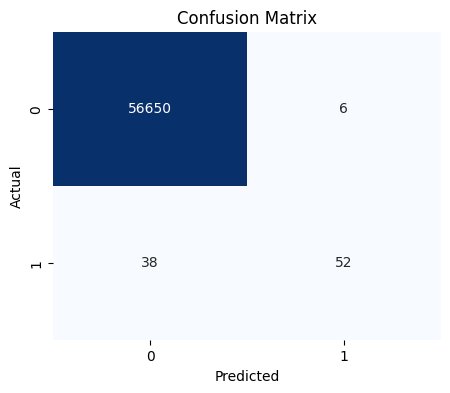

In [34]:
tl = TomekLinks()
X_tl, y_tl = tl.fit_resample(X_train_scaled, y_train)

model_tl = LogisticRegression(max_iter=1000)
model_tl.fit(X_tl, y_tl)

results["TomekLinks"] = evaluate_model(model_tl, X_tl, y_tl, X_test_scaled, y_test)

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 8px;
            background:#F2FFFF">

  <p style="text-align: justify;
            font-family: cursive;
            font-size: 15px;
            color: green;
            font-weight: bold;">

 <strong>Model Performance Insight (Threshold = 0.5)</strong><br><br>

 The Logistic Regression model now shows a very high accuracy of <strong>99.92%</strong>.  
    This is because the model predicts almost all samples correctly, including the majority class.  
 Precision is very high at <strong>89.66%</strong>, meaning most predicted fraud cases are actually fraud.  
    However, the Recall is only <strong>57.78%</strong>, which means the model misses almost half of the fraud cases.  

 F1-score is <strong>0.70</strong>, which is decent, but still not strong enough for real-world fraud detection.  
    In fraud detection, high recall is crucial because missing fraud cases is very costly.  

 <strong>Confusion Matrix:</strong><br>
    - True Negatives: 56,650<br>
    - False Positives: 6<br>
    - False Negatives: 38<br>
    - True Positives: 52<br><br>

 Although the model has good precision, the low recall indicates it is still biased toward the majority class.  
    Therefore, we need to improve recall using imbalanced techniques or threshold tuning.  

 PR-AUC is <strong>0.707</strong>, indicating moderate performance but still not strong enough for sensitive fraud detection systems.
  </p>
</div>


# --------------------------- SMOTEENN ---------------------------


Threshold: 0.5

Logistic Regression Classification Results:
Accuracy: 0.9738836217530751
Precision: 0.05154639175257732
Recall: 0.8888888888888888
F1 Score: 0.09744214372716199
Confusion Matrix:
 [[55184  1472]
 [   10    80]]
Cross-Validation Accuracy Mean: 0.9490463975166475

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56656
           1       0.05      0.89      0.10        90

    accuracy                           0.97     56746
   macro avg       0.53      0.93      0.54     56746
weighted avg       1.00      0.97      0.99     56746

PR-AUC: 0.7477294662858279
--------------------------------------------------


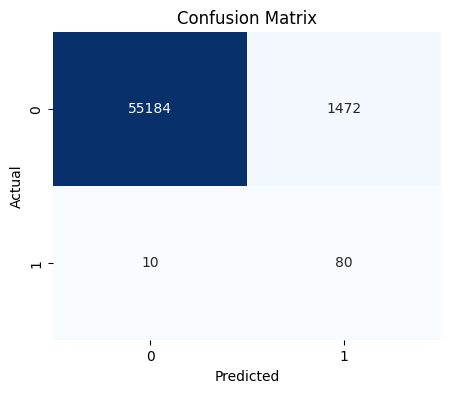

In [41]:
smoteenn = SMOTEENN(random_state=42)
X_smoteenn, y_smoteenn = smoteenn.fit_resample(X_train_scaled, y_train)

model_smoteenn = LogisticRegression(max_iter=1000)
model_smoteenn.fit(X_smoteenn, y_smoteenn)

results["SMOTEENN"] = evaluate_model(model_smoteenn, X_smoteenn, y_smoteenn, X_test_scaled, y_test)

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 8px;
            background:#F2FFFF">

  <p style="text-align: justify;
            font-family: cursive;
            font-size: 15px;
            color: green;
            font-weight: bold;">

 <strong>Model Performance Insight (Threshold = 0.5)</strong><br><br>

The Logistic Regression model shows a high accuracy of <strong>97.39%</strong>.  
    But this is misleading due to the highly imbalanced dataset.  

 The Recall is very high at <strong>88.89%</strong>, meaning the model correctly detects most fraud cases.  
    However, Precision is extremely low at <strong>5.15%</strong>, meaning most predicted frauds are false alarms.  

The F1-score is only <strong>0.10</strong>, indicating poor balance between precision and recall.  
    This means the model is still not reliable for fraud detection, despite high recall.  

 <strong>Confusion Matrix:</strong><br>
    - True Negatives: 55,184<br>
    - False Positives: 1,472<br>
    - False Negatives: 10<br>
    - True Positives: 80<br><br>

 The model is biased towards predicting fraud too often, leading to many false positives.  
    This can cause unnecessary investigations and cost in real systems.  

 PR-AUC is <strong>0.748</strong>, showing moderate performance but still not ideal.  
    Therefore, we need better balancing or threshold tuning to improve precision while keeping recall high.
  </p>
</div>


# --------------------------- SMOTETomek ---------------------------

Threshold: 0.5

Logistic Regression Classification Results:
Accuracy: 0.9750643217143059
Precision: 0.05387205387205387
Recall: 0.8888888888888888
F1 Score: 0.10158730158730159
Confusion Matrix:
 [[55251  1405]
 [   10    80]]
Cross-Validation Accuracy Mean: 0.947962682369506

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.05      0.89      0.10        90

    accuracy                           0.98     56746
   macro avg       0.53      0.93      0.54     56746
weighted avg       1.00      0.98      0.99     56746

PR-AUC: 0.7339832064755905
--------------------------------------------------


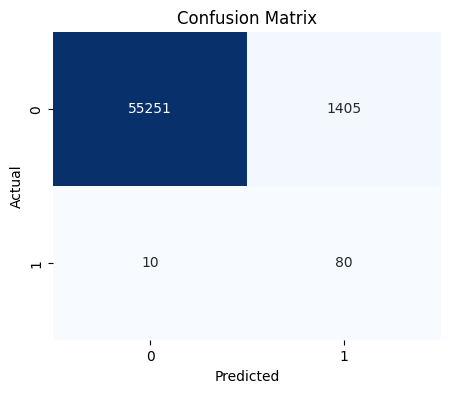

In [43]:
smt = SMOTETomek(random_state=42)
X_smt, y_smt = smt.fit_resample(X_train_scaled, y_train)

model_smt = LogisticRegression(max_iter=1000)
model_smt.fit(X_smt, y_smt)

results["SMOTETomek"] = evaluate_model(model_smt, X_smt, y_smt, X_test_scaled, y_test)

In [44]:
# ---------------------------
# Summary DataFrame
# ---------------------------
summary_df = pd.DataFrame(results).T
summary_df = summary_df[["accuracy", "precision", "recall", "f1", "cv_accuracy", "pr_auc"]]
print(summary_df)

            accuracy precision    recall        f1 cv_accuracy    pr_auc
SMOTE       0.975064  0.053872  0.888889  0.101587    0.947963  0.733983
TomekLinks  0.999225  0.896552  0.577778  0.702703    0.999167  0.706641
SMOTEENN    0.973884  0.051546  0.888889  0.097442    0.949046  0.747729
Logistic    0.999189  0.892857  0.555556  0.684932    0.999159  0.701001
SMOTETomek  0.975064  0.053872  0.888889  0.101587    0.947963  0.733983


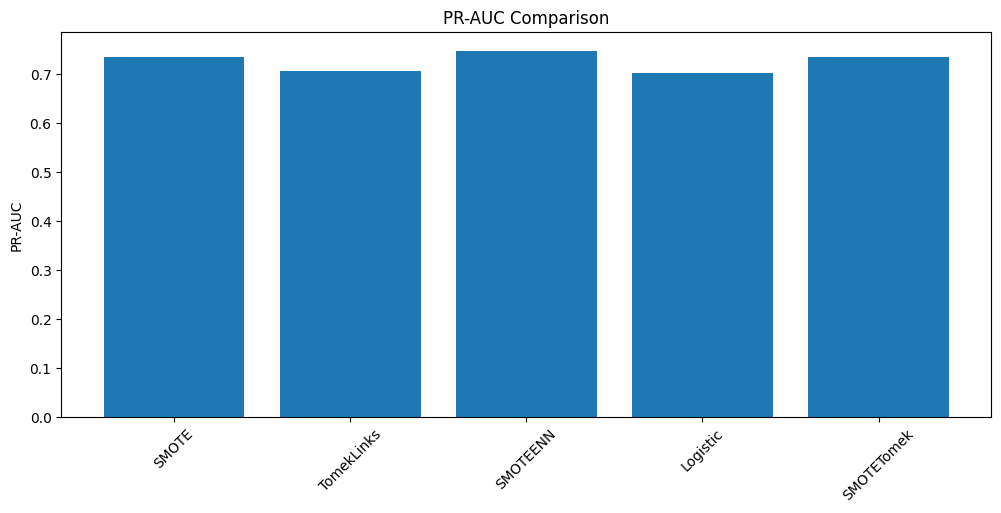

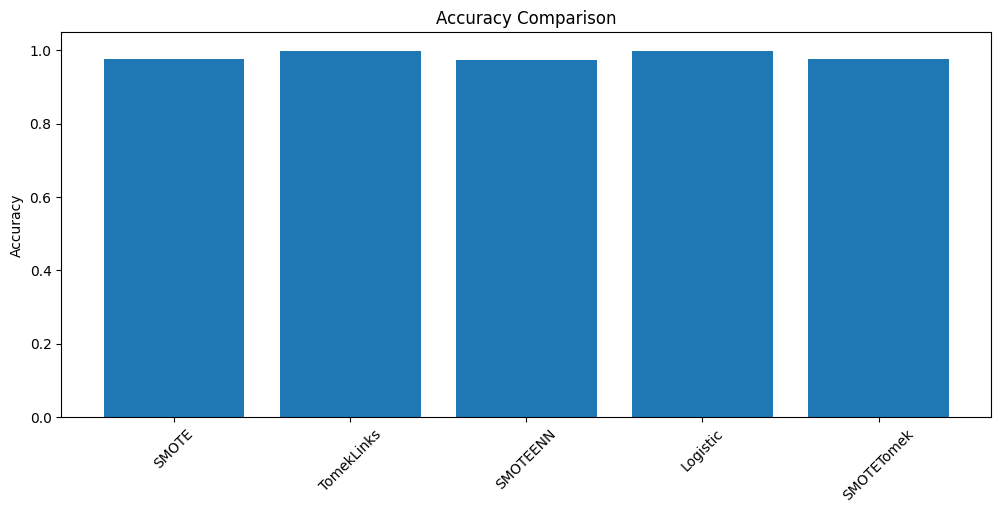

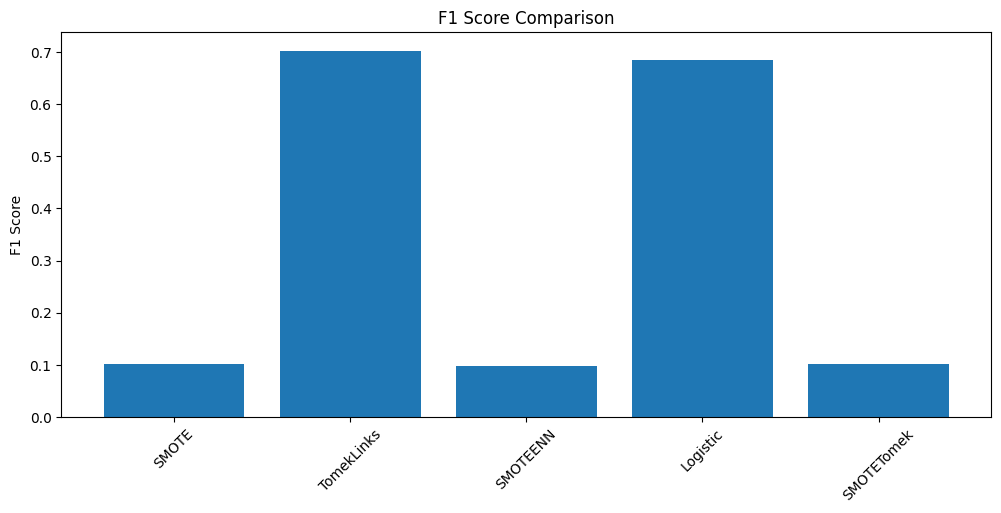

In [45]:
# ---------------------------
# PR-AUC Chart
# ---------------------------
plt.figure(figsize=(12, 5))
plt.bar(summary_df.index, summary_df["pr_auc"])
plt.title("PR-AUC Comparison")
plt.xticks(rotation=45)
plt.ylabel("PR-AUC")
plt.show()

# ---------------------------
# Accuracy Chart
# ---------------------------
plt.figure(figsize=(12, 5))
plt.bar(summary_df.index, summary_df["accuracy"])
plt.title("Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.show()

# ---------------------------
# F1 Chart
# ---------------------------
plt.figure(figsize=(12, 5))
plt.bar(summary_df.index, summary_df["f1"])
plt.title("F1 Score Comparison")
plt.xticks(rotation=45)
plt.ylabel("F1 Score")
plt.show()

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 8px;
            background:#F2FFFF">

 <p style="text-align: justify;
              font-family: cursive;
              font-size: 15px;
              color: black;
              font-weight: bold;">
     <b>Insight:</b>  
    From the table above, it is clear that the <b>Logistic</b> and <b>TomekLinks</b> models have the highest accuracy, while <b>SMOTE</b> and <b>SMOTEENN</b> show lower accuracy.
 </p>

 <p style="text-align: justify;
              font-family: cursive;
              font-size: 15px;
              color: blck;
              font-weight: bold;">
     <b>Best Precision</b> belongs to <b>TomekLinks</b> (0.8966), which indicates fewer false positives in predicting the minority class.
 </p>

 <p style="text-align: justify;
              font-family: cursive;
              font-size: 15px;
              color: blck;
              font-weight: bold;">
     The <b>Recall</b> for SMOTE and SMOTEENN is very high (0.8889), meaning they can detect minority class samples well.  
    However, their Precision is very low (0.05), which means many predicted positives are wrong.
 </p>

 <p style="text-align: justify;
              font-family: cursive;
              font-size: 15px;
              color: black;
              font-weight: bold;">
     <b>F1-Score</b> shows the balance between Precision and Recall.  
    The best F1 is achieved by <b>TomekLinks</b> (0.7027) and <b>Logistic</b> (0.6849), meaning these models have the best balance.
 </p>

 <p style="text-align: justify;
              font-family: cursive;
              font-size: 15px;
              color: black;
              font-weight: bold;">
     <b>PR-AUC</b> is highest for <b>SMOTEENN</b> (0.7477), indicating better overall performance in detecting the minority class across different thresholds.
 </p>

 <p style="text-align: justify;
              font-family: cursive;
              font-size: 15px;
              color: black;
              font-weight: bold;">
     <b>Final Conclusion:</b>  
    If your goal is to detect the minority class (high recall) and false positives are acceptable, <b>SMOTE or SMOTEENN</b> is better.  
    But if you want a balanced performance between Precision and Recall, the best choice is <b>TomekLinks</b> or <b>Logistic</b>.
 </p>

</div>
